# Cruce semaforico personalizado

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mesa as ms
from scipy.interpolate import CubicSpline

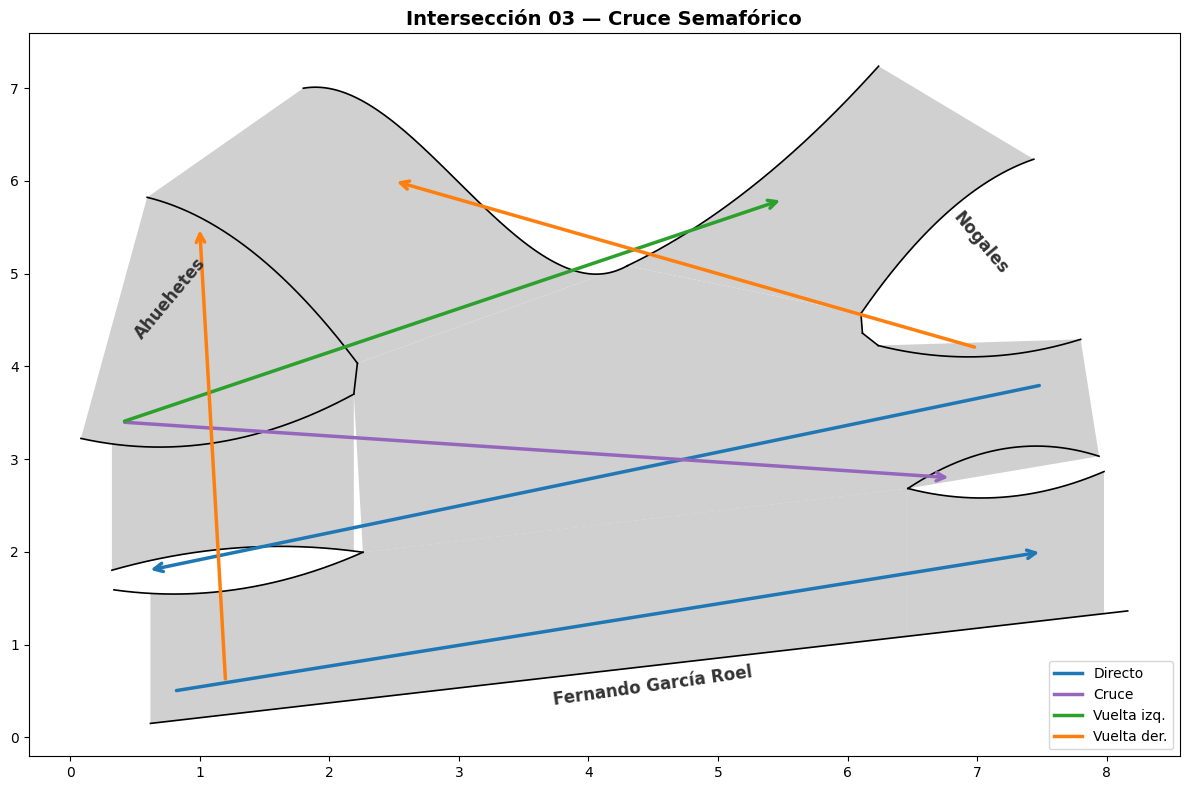

In [39]:
segments1 = [
    np.array([
        (0.0841186884343,3.2234249352397),
        (1.8896856850202,3.4956488824173),
        (2.1896875859914,3.7012057404902)
    ]),
    np.array([
        (2.1896875859914,3.7012057404902),
        (2.217465539785,4.0345411860137)
    ]),
    np.array([
        (2.217465539785,4.0345411860137),
        (2.0785757708169,4.2845427701564),
        (0.5952330382371,5.8234414103235),
    ]),
    np.array([
        (0.6206003845145,0.1504929130135),
        (8.160933216644,1.363582623598),
    ]),
    np.array([
        (0.3393581425586,1.5906149757276),
        (2.0767117990044,1.8898258832266),
        (2.260099129407,1.9959974955649)
    ]),
    np.array([
        (2.260099129407,1.9959974955649),
        (2.0440673555766,2.0315721993294),
        (0.3231737784836,1.8025633155969)
    ]),
    np.array([
        (7.9783177708744,2.8662140495399),
        (6.6135245220345,2.6373356786165),
        (6.4651774297693,2.6839590504712)
    ]),
    np.array([
        (6.4651774297693,2.6839590504712),
        (6.6,2.8),
        (7.9401713757205,3.0315150952069)
    ]),
    np.array([
        (7.7979759592378,4.2920532319005),
        (6.479541790236,4.1547163392961),
        (6.2362592947654,4.2253467412069)
    ]),
    np.array([
        (6.2362592947654,4.2253467412069),
        (6.1146180470302,4.358759722594)
    ]),
    np.array([
        (6.1146180470302,4.358759722594),
        (6.1028463133784,4.5706509283264)
    ]),
    np.array([
        (6.1028463133784,4.5706509283264),
        (6.2048680050273,4.7707704004071),
        (7.4369761272492,6.2343892844477)
    ]),
    np.array([
        (6.2388507634862,7.2375484825859),
        (4.4724084238976,5.2071549888058),
        (4.2998249769263,5.085331379179)
    ]),
    np.array([
        (4.2998249769263,5.085331379179),
        (4,5),
        (3.7414667661368,5.1208632653202),
        (3.60371505793,5.2370820098871),
        (1.8,7)
    ])
]

# --- Compute all spline curves ---
from scipy.interpolate import interp1d
from matplotlib.lines import Line2D

def compute_spline(points, n=300):
    x, y = points[:, 0], points[:, 1]
    sort_idx = np.argsort(x)
    x, y = x[sort_idx], y[sort_idx]
    cs = CubicSpline(x, y)
    x_fine = np.linspace(x[0], x[-1], n)
    y_fine = cs(x_fine)
    return np.column_stack([x_fine, y_fine])

curves = [compute_spline(seg) for seg in segments1]

fig, ax = plt.subplots(figsize=(12, 8))

ROAD_COLOR = '#d0d0d0'

# --- Helper: fill between two curves sharing an x-range ---
def fill_road(c_bottom, c_top):
    x_min = max(c_bottom[0, 0], c_top[0, 0])
    x_max = min(c_bottom[-1, 0], c_top[-1, 0])
    if x_min >= x_max:
        return
    x = np.linspace(x_min, x_max, 300)
    f_bot = interp1d(c_bottom[:, 0], c_bottom[:, 1], fill_value='extrapolate')
    f_top = interp1d(c_top[:, 0], c_top[:, 1], fill_value='extrapolate')
    ax.fill_between(x, f_bot(x), f_top(x), color=ROAD_COLOR, edgecolor='none', zorder=1)

# --- 1. Road fill ---

# F.G. Roel lower-left lane: between c3 (bottom) and c4 (top)
fill_road(curves[3], curves[4])

# Upper-left lane: between c5 (bottom) and c0 (top)
fill_road(curves[5], curves[0])

# F.G. Roel lower-right lane: between c3 (bottom) and c6 (top)
fill_road(curves[3], curves[6])

# Upper-right lane: between c7 (bottom) and c8 (top)
fill_road(curves[7], curves[8])

# F.G. Roel through section (between left and right arms)
# Bottom: c3, Top: line from c4 end to c6 start
x_left = curves[4][-1]   # ~(2.26, 2.00)
x_right = curves[6][0]   # ~(6.47, 2.68)
x_through = np.linspace(x_left[0], x_right[0], 300)
f_c3 = interp1d(curves[3][:, 0], curves[3][:, 1], fill_value='extrapolate')
y_bot_through = f_c3(x_through)
y_top_through = np.interp(x_through, [x_left[0], x_right[0]], [x_left[1], x_right[1]])
ax.fill_between(x_through, y_bot_through, y_top_through, color=ROAD_COLOR, edgecolor='none', zorder=1)

# Upper through section: between divider top and intersection
x_left_u = curves[5][-1]  # ~(2.26, 2.03)
x_right_u = curves[7][0]  # ~(6.47, 2.68)
x_through_u = np.linspace(x_left_u[0], x_right_u[0], 300)
y_bot_u = np.interp(x_through_u, [x_left_u[0], x_right_u[0]], [x_left_u[1], x_right_u[1]])
y_top_u = np.interp(x_through_u,
    [curves[0][-1][0], curves[8][0][0]],
    [curves[0][-1][1], curves[8][0][1]])
ax.fill_between(x_through_u, y_bot_u, y_top_u, color=ROAD_COLOR, edgecolor='none', zorder=1)

# Ahuehetes arm: c0 -> c1 -> c2 reversed
poly_ahue = np.vstack([curves[0], curves[1], curves[2][::-1]])
ax.fill(poly_ahue[:, 0], poly_ahue[:, 1], color=ROAD_COLOR, edgecolor='none', zorder=1)

# Central intersection zone
intersection_pts = np.array([
    curves[4][-1],   # ~(2.26, 2.00)
    curves[6][0],    # ~(6.47, 2.68)
    curves[7][-1],   # ~(7.94, 3.03)
    curves[8][-1],   # ~(7.80, 4.29)
    curves[8][0],    # ~(6.24, 4.23)
    curves[9][0],    # ~(6.11, 4.36)
    curves[10][0],   # ~(6.10, 4.57)
    curves[12][0],   # ~(4.30, 5.09)
    curves[1][-1],   # ~(2.22, 4.03)
    curves[0][-1],   # ~(2.19, 3.70)
])
ax.fill(intersection_pts[:, 0], intersection_pts[:, 1], color=ROAD_COLOR, edgecolor='none', zorder=1)

# Upper NW section: left edge c2, right edge c13
poly_nw = np.vstack([curves[2][::-1], curves[13]])
ax.fill(poly_nw[:, 0], poly_nw[:, 1], color=ROAD_COLOR, edgecolor='none', zorder=1)

# Nogales NE arm: left edge c12, right edge c11
poly_ne = np.vstack([curves[12], curves[11][::-1]])
ax.fill(poly_ne[:, 0], poly_ne[:, 1], color=ROAD_COLOR, edgecolor='none', zorder=1)

# --- 2. Road edge lines ---
for c in curves:
    ax.plot(c[:, 0], c[:, 1], color='k', linewidth=1.2, zorder=2)

# --- 3. Street name labels ---
ax.text(0.8, 4.7, 'Ahuehetes', fontsize=12, fontweight='bold', color='#333',
        rotation=50, ha='center', rotation_mode='anchor', zorder=4)
ax.text(7.0, 5.3, 'Nogales', fontsize=12, fontweight='bold', color='#333',
        rotation=-50, ha='center', rotation_mode='anchor', zorder=4)
ax.text(4.5, 0.5, 'Fernando García Roel', fontsize=12, fontweight='bold', color='#333',
        rotation=8, ha='center', rotation_mode='anchor', zorder=4)

# --- 4. Direction arrows ---
arrow_kw = dict(arrowstyle='->', lw=2.5, mutation_scale=15)

arrows = [
    ((0.8, 0.5),  (7.5, 2.0),  '#1f77b4'),   # F.G.Roel W -> E (directo)
    ((7.5, 3.8),  (0.6, 1.8),  '#1f77b4'),   # F.G.Roel E -> W (directo)
    ((0.4, 3.4),  (6.8, 2.8),  '#9467bd'),   # Ahuehetes -> F.G.Roel E (cruce)
    ((0.4, 3.4),  (5.5, 5.8),  '#2ca02c'),   # Ahuehetes -> Nogales NE (vuelta izq)
    ((1.2, 0.6),  (1.0, 5.5),  '#ff7f0e'),   # F.G.Roel -> Ahuehetes (vuelta der)
    ((7.0, 4.2),  (2.5, 6.0),  '#ff7f0e'),   # Nogales -> Ahuehetes (vuelta der)
]

for start, end, color in arrows:
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(**arrow_kw, color=color), zorder=3)

# --- 5. Legend ---
legend_elements = [
    Line2D([0], [0], color='#1f77b4', lw=2.5, label='Directo'),
    Line2D([0], [0], color='#9467bd', lw=2.5, label='Cruce'),
    Line2D([0], [0], color='#2ca02c', lw=2.5, label='Vuelta izq.'),
    Line2D([0], [0], color='#ff7f0e', lw=2.5, label='Vuelta der.'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.set_title('Intersección 03 — Cruce Semafórico', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()